In [35]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embedding_function = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3"
)

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name="income_tax_collection",
    persist_directory="./income_tax_collection"
)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 52667.89it/s]


In [36]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [53]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [38]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

In [39]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {"context": docs}

In [40]:
from langsmith import Client
from langchain_google_genai import ChatGoogleGenerativeAI

client = Client()
generate_prompt = client.pull_prompt(
    "rlm/rag-prompt",
    dangerously_pull_public_prompt=True,
)
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [41]:
def generate(state: AgentState):
    context = state["context"]
    question = state["query"]
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({"question": question, "context": context})
    return {"answer": response}

In [42]:
relevance_prompt = client.pull_prompt(
    "langchain-ai/rag-document-relevance",
    dangerously_pull_public_prompt=True,
)

In [58]:
from typing import Literal

def check_relevance(state: AgentState) -> Literal['generate', 'rewrite']:
    context = state["context"]
    print(f'context == {context}')
    question = state["query"]
    relevance_chain = relevance_prompt | llm
    response = relevance_chain.invoke({"question": question, "documents": context})
    print(f'doc relevanceresponse == {response}')
    if response['Score'] == 1:
        return 'generate'
    return 'rewrite'

In [45]:
query = "연봉 5천만원 직장인의 소득세는?"

In [46]:
from langchain_core.prompts import PromptTemplate

dictionary = ['사람과 관련된 표현 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(
    f"""
    사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.
    만약 변경할 필요가 없다고 판단된다면, 사용자의 질문을 변경하지 않아도 됩니다.
    사전: {dictionary}
    질문: {{query}}
    """
)

In [47]:
from langchain_core.output_parsers import StrOutputParser

def rewrite(state: AgentState):
    question = state["query"]
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({"query": question})
    return {"query": response}


In [54]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

In [55]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges('retrieve', check_relevance)
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)


In [56]:
graph = graph_builder.compile()

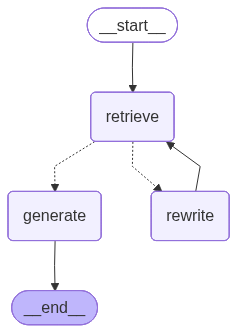

In [57]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = {'query': '연봉 5천만원 세금'}
graph.invoke(initial_state)